In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import qutip as qt

In [2]:
kappa = 1.0
N = 80

xvec = np.linspace(-8, 8, 301)
yvec = np.linspace(-8, 8, 301)

def cat_state(alpha_cat, alpha_disp, N=N):
    """Return normalized |alpha_disp+i alpha_cat> + |alpha_disp-i alpha_cat>."""
    beta_plus  = alpha_disp + 1j * alpha_cat
    beta_minus = alpha_disp - 1j * alpha_cat
    psi = qt.coherent(N, beta_plus) + qt.coherent(N, beta_minus)
    return psi.unit()


def evolve_states(psi0, tau_list, kappa=kappa, N=N):
    """
    Evolve a state under photon loss.
    tau_list = kappa * t is dimensionless time.
    """
    a = qt.destroy(N)
    H = 0 * a.dag() * a
    c_ops = [np.sqrt(kappa) * a]
    tlist = np.asarray(tau_list) / kappa
    return qt.mesolve(H, psi0, tlist, c_ops, e_ops=[])


def wigner_line_y0(rho, xvec=xvec, y0=0.0):
    """Return W(x, y0) as a 1D array."""
    return np.squeeze(np.real(qt.wigner(rho, xvec, np.array([y0]))))


def peak_on_x_line(rho, xvec=xvec, y0=0.0):
    """Return (xmax, Wmax) for W(x, y0)."""
    line = wigner_line_y0(rho, xvec=xvec, y0=y0)
    idx = np.argmax(line)
    return xvec[idx], line[idx]


def get_wigner_peaks(states, xvec=xvec):
    """Compute W(xmax, 0) for every state in states."""
    xmaxs, peaks = [], []
    for rho in states:
        xmax, peak = peak_on_x_line(rho, xvec=xvec, y0=0.0)
        xmaxs.append(xmax)
        peaks.append(peak)
    return np.array(xmaxs), np.array(peaks)


def exp_no_offset(tau, A, gamma):
    return A * np.exp(-gamma * tau)


def fit_whisker_rate(tau, peaks, alpha_cat, kappa=kappa):
    """Fit W(xmax,0) to A exp(-gamma tau) over all time points."""
    tau = np.asarray(tau)
    peaks = np.asarray(peaks)
    popt, _ = curve_fit(
        exp_no_offset,
        tau,
        peaks,
        p0=[peaks[0], 2 * alpha_cat**2 * kappa],
        bounds=([0, 0], [np.inf, np.inf]),
        maxfev=20000,
    )
    A_fit, gamma_fit = popt
    return gamma_fit, A_fit


def fit_nbar_rate(tau, nbar, kappa=kappa):
    """Fit <a^dag a> to A exp(-gamma tau)."""
    tau = np.asarray(tau)
    nbar = np.asarray(nbar)
    popt, _ = curve_fit(
        exp_no_offset,
        tau,
        nbar,
        p0=[nbar[0], kappa],
        bounds=([0, 0], [np.inf, np.inf]),
        maxfev=20000,
    )
    A_fit, gamma_fit = popt
    return gamma_fit, A_fit

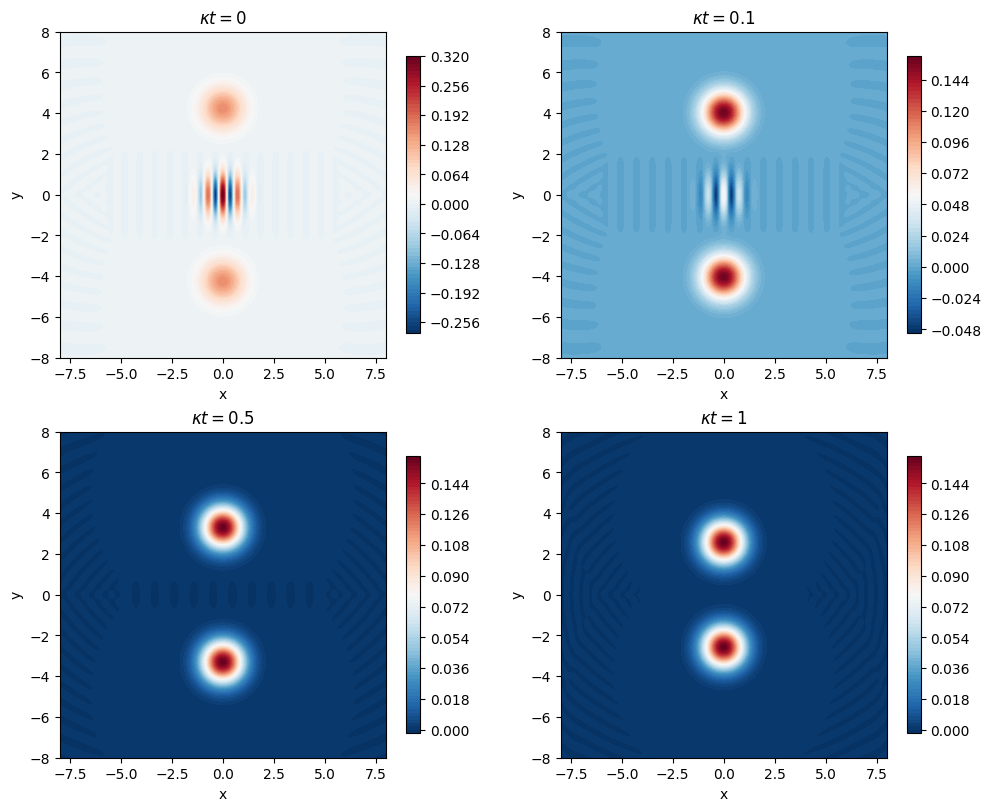

In [3]:
alpha_cat = 3.0
psi0 = cat_state(alpha_cat=alpha_cat, alpha_disp=0.0)

tau_a = np.array([0.0, 0.1, 0.5, 1.0])     # tau = kappa t
result_a = evolve_states(psi0, tau_a)

fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
axes = axes.ravel()

for ax_i, rho, tau in zip(axes, result_a.states, tau_a):
    W = qt.wigner(rho, xvec, yvec)
    im = ax_i.contourf(xvec, yvec, W, levels=80, cmap="RdBu_r")
    ax_i.set_title(rf"$\kappa t = {tau:g}$")
    ax_i.set_xlabel("x")
    ax_i.set_ylabel("y")
    ax_i.set_aspect("equal")
    fig.colorbar(im, ax=ax_i, shrink=0.85)

plt.show()


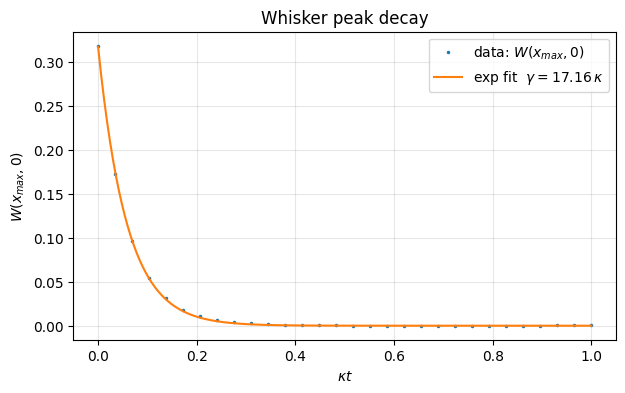

Fitted whisker decay rate = 17.161 kappa
Expected 2*alpha_cat^2 = 18.000 kappa


In [15]:
# Use many time points because the whisker decay is fast for alpha_cat=3.
alpha_cat = 3.0
psi0 = cat_state(alpha_cat=alpha_cat, alpha_disp=0.0)
tau = np.linspace(0, 1.0, 30)
result_b = evolve_states(psi0, tau)

xmaxs, peaks = get_wigner_peaks(result_b.states, xvec=xvec)

gamma_w, A_w = fit_whisker_rate(tau, peaks, alpha_cat=alpha_cat)

tau_smooth = np.linspace(tau[0], tau[-1], 500)

plt.figure(figsize=(7, 4))
plt.plot(tau, peaks, ".", ms=3, label=r"data: $W(x_{max},0)$")
plt.plot(tau_smooth, exp_no_offset(tau_smooth, A_w, gamma_w), "-",
         label=rf"exp fit  $\gamma = {gamma_w:.2f}\,\kappa$")
plt.xlabel(r"$\kappa t$")
plt.ylabel(r"$W(x_{max},0)$")
plt.title("Whisker peak decay")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Fitted whisker decay rate = {gamma_w:.3f} kappa")
print(f"Expected 2*alpha_cat^2 = {2*alpha_cat**2:.3f} kappa")

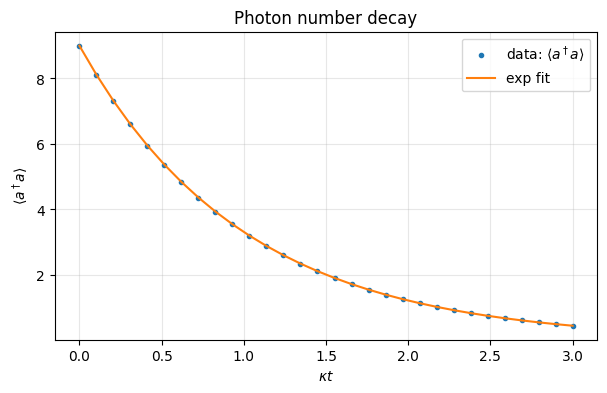

Initial <n> = 9.000
Fitted photon-number decay rate = 1.000 kappa


In [13]:
# Here we ask mesolve directly for the expectation value of n = a^dag a.
tau = np.linspace(0, 3.0, 30)
H = 0 * qt.destroy(N).dag() * qt.destroy(N)

psi0 = cat_state(alpha_cat=3.0, alpha_disp=0.0)
a = qt.destroy(N)
c_ops = [np.sqrt(kappa) * a]
n_op = a.dag() * a
res_n = qt.mesolve(H, psi0, tau / kappa, c_ops, e_ops=[n_op])
nbar = np.real(res_n.expect[0])

gamma_n, A_n = fit_nbar_rate(tau, nbar)

plt.figure(figsize=(7, 4))
plt.plot(tau, nbar, ".", label=r"data: $\langle a^\dagger a\rangle$")
plt.plot(tau, exp_no_offset(tau, A_n, gamma_n), "-", label="exp fit")
plt.xlabel(r"$\kappa t$")
plt.ylabel(r"$\langle a^\dagger a\rangle$")
plt.title("Photon number decay")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Initial <n> = {nbar[0]:.3f}")
print(f"Fitted photon-number decay rate = {gamma_n:.3f} kappa")


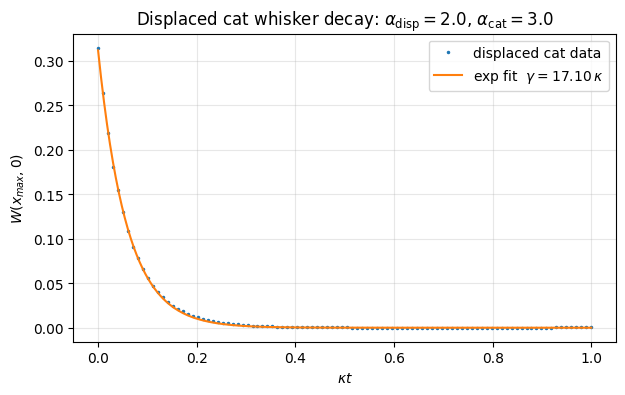

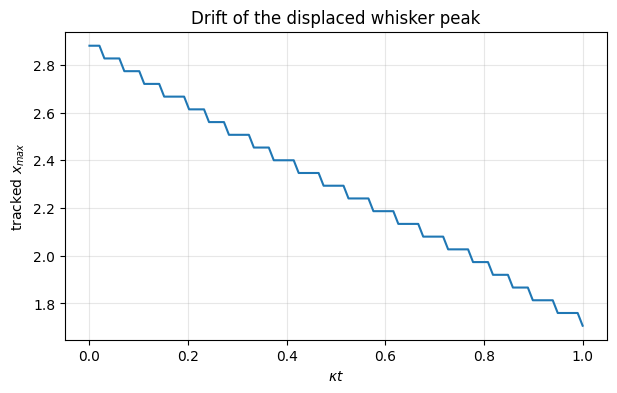

Displaced-cat fitted whisker decay rate   = 17.099 kappa
Undisplaced-cat fitted whisker decay rate = 17.161 kappa
Expected 2*alpha_cat^2 = 18.000 kappa


In [19]:
alpha_disp = 2.0
alpha_cat = 3.0
tau = np.linspace(0, 1.0, 100)
psi_disp = cat_state(alpha_cat=alpha_cat, alpha_disp=alpha_disp)

result_c = evolve_states(psi_disp, tau)
xmaxs_disp, peaks_disp = get_wigner_peaks(result_c.states, xvec=xvec)

gamma_w_disp, A_w_disp = fit_whisker_rate(tau, peaks_disp, alpha_cat)

tau_smooth = np.linspace(tau[0], tau[-1], 500)

plt.figure(figsize=(7, 4))
plt.plot(tau, peaks_disp, ".", ms=3, label=r"displaced cat data")
plt.plot(tau_smooth, exp_no_offset(tau_smooth, A_w_disp, gamma_w_disp), "-",
         label=rf"exp fit  $\gamma = {gamma_w_disp:.2f}\,\kappa$")
plt.xlabel(r"$\kappa t$")
plt.ylabel(r"$W(x_{max},0)$")
plt.title(rf"Displaced cat whisker decay: $\alpha_{{\rm disp}}={alpha_disp}$, $\alpha_{{\rm cat}}={alpha_cat}$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(tau, xmaxs_disp)
plt.xlabel(r"$\kappa t$")
plt.ylabel(r"tracked $x_{max}$")
plt.title("Drift of the displaced whisker peak")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Displaced-cat fitted whisker decay rate   = {gamma_w_disp:.3f} kappa")
print(f"Undisplaced-cat fitted whisker decay rate = {gamma_w:.3f} kappa")
print(f"Expected 2*alpha_cat^2 = {2*alpha_cat**2:.3f} kappa")